In [74]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Data Inspection and Feature Creation

In this section we check the data structures, create variables to ease future calculation
- Convert date to date time format
- Calculate delivery fee per kilometers
- create post, region, unit_discount_applied, delivery_discount_applied dummy variable

In [75]:
# Load
df = pd.read_csv("GP3_Data.csv")

# Inspect data structure
print(df.head())
print(df.dtypes)

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Calculate delivery fee per km
df["delivery_fee_per_km"] = df["Delivery Fees"] / df["Distance"]

# Create "post" variable (policy starts Mar 1)
df["post"] = (df["Date"] >= "2023-03-01").astype(int)

# Region dummies
df_dummy = pd.get_dummies(df["Region"], prefix="R", drop_first=False)
df = pd.concat([df, df_dummy], axis=1)

# Create Unit Discount Applied (Region 3 only)
df["unit_discount_applied"] = ((df["Discount Applied"] == 1) & (df["Region"] == 3)).astype(int)

# Create Delivery Discount Applied (Region 4 only)
df["delivery_discount_applied"] = ((df["Discount Applied"] == 1) & (df["Region"] == 4)).astype(int)

         Date  Region  Unit Price  Quantity Ordered  Distance  Delivery Fees  \
0  2023-01-01       1        16.0                21         2            1.0   
1  2023-01-01       2        16.0                18         5            2.5   
2  2023-01-01       3        16.0                10         9            4.5   
3  2023-01-01       4        16.0                 1        15            7.5   
4  2023-01-02       1        16.0                20         2            1.0   

   Discount Applied  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  
Date                 object
Region                int64
Unit Price          float64
Quantity Ordered      int64
Distance              int64
Delivery Fees       float64
Discount Applied      int64
dtype: object


# 2. Check data quality, consistency, fix values if needed
- There shouldn't be any nullable values in data
- The unit price should be 16, 15.2 represent no discount and discounted prizza price respectively.
- The flag unit_discount_applied should be consistent with the pizza price, no exception should exists.
- The per km delivery fees should be 0.5 and 0.475 resepectively, represent no discount and discounted delivery fee respectively.
- The flag delivery_discount_applied should be consistent with delivery fees, no exception should exists.

In [76]:
# Check data quality
print(df.isnull().sum())

# Check the values for Unit Price, there are only 2 values, 16 and 15.2 which correspond to no discount and discount respectively
print(df["Unit Price"].unique())

# Check the flag consistency with Unit Price When Apply Discount = 1, Unit Price should be 15.2, the reverse is also true, other than the above there should be no other combinations
p15 = np.isclose(df["Unit Price"], 15.2)
flag1 = df["unit_discount_applied"] == 1
inconsistent_any = (flag1 & ~p15) | (p15 & ~flag1)
print("Number of inconsistent records for pizza price discount: ", inconsistent_any.sum())

# Check the values for Delivery Fee per km, there are only 2 values, 0.5 and 0.475 which correspond to no discount and discount respectively
print(df["delivery_fee_per_km"].unique())
# Check the flag consistency with Delivery Fee When Apply Discount = 1, delivery_fee_per_km should be 0.475, the reverse is also true, other than the above there should be no other combinations
p0475 = np.isclose(df["delivery_fee_per_km"], 0.475)
flag1 = df["delivery_discount_applied"] == 1
inconsistent_any = (flag1 & ~p0475) | (p0475 & ~flag1)
print("Number of inconsistent records for delivery fee discount: ", inconsistent_any.sum())


Date                         0
Region                       0
Unit Price                   0
Quantity Ordered             0
Distance                     0
Delivery Fees                0
Discount Applied             0
delivery_fee_per_km          0
post                         0
R_1                          0
R_2                          0
R_3                          0
R_4                          0
unit_discount_applied        0
delivery_discount_applied    0
dtype: int64
[16.  15.2]
Number of inconsistent records for pizza price discount:  0
[0.5   0.475]
Number of inconsistent records for delivery fee discount:  0


# 3. Demand Observation before treatment vs after treatment
Check whether the quantity changed after applying different discounts, observe the quantity before and after discount for each region. We can see that after applying discount, the average quantity ordered for region 1, 2 are decreasing slightly(control group) and for region 3 and 4 (treatement group) are increasing.

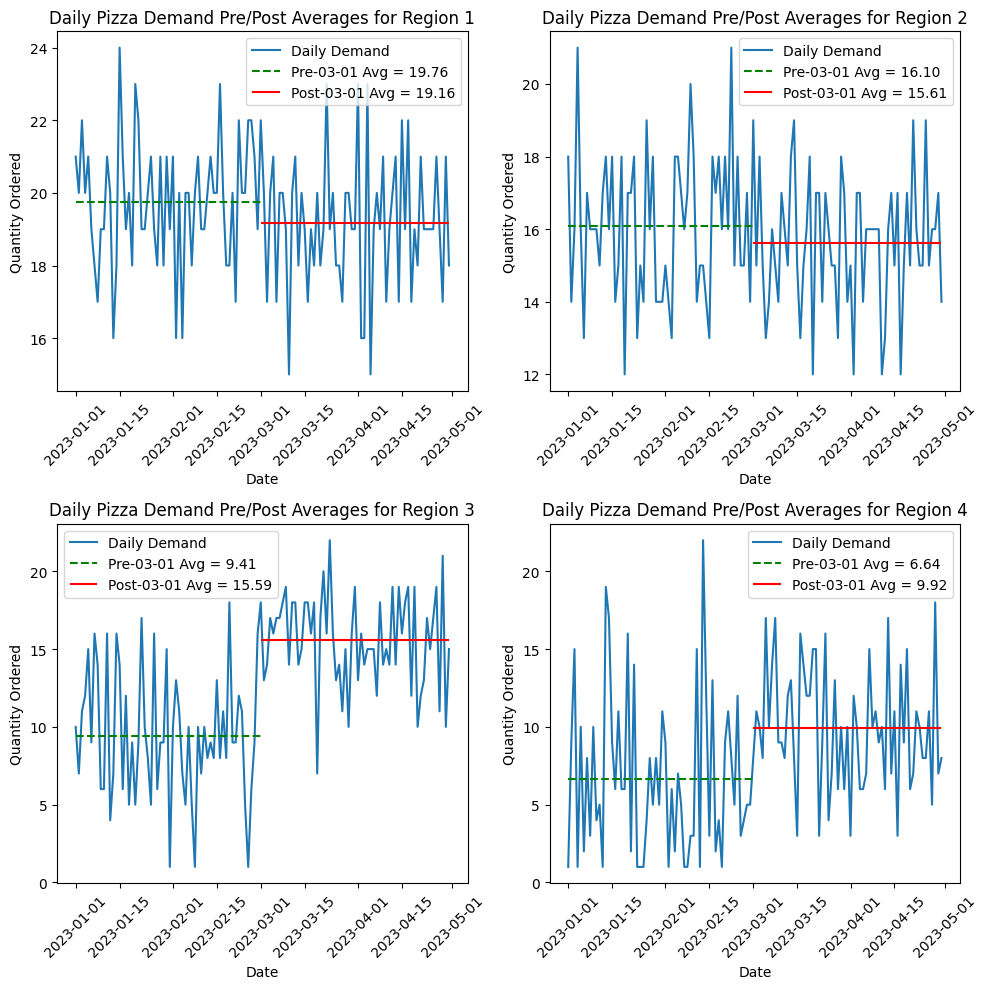

In [77]:
# Function for ploting daily demand with pre and post average lines for region x
def plot_daily_demand_region(df, axes, daily_region, cutoff, region_num):
  # === Line chart with segmented average lines ===
  pre_avg = daily_region[daily_region.index < cutoff].mean()
  post_avg = daily_region[daily_region.index >= cutoff].mean()

  axes.plot(daily_region.index, daily_region.values, label="Daily Demand")
  # Pre-policy average line: from min date to cutoff
  axes.hlines(pre_avg,
    xmin=daily_region.index.min(),
    xmax=cutoff,
    linestyles="--",
    color = "green",
    label=f"Pre-03-01 Avg = {pre_avg:.2f}")

  # Post-policy average line: from cutoff to max date
  axes.hlines(post_avg,
            xmin=cutoff,
            xmax=daily_region.index.max(),
            color = "red",
            linestyles="-",
            label=f"Post-03-01 Avg = {post_avg:.2f}")

  axes.set_title(f"Daily Pizza Demand Pre/Post Averages for Region {region_num}")
  axes.set_xlabel("Date")
  axes.set_ylabel("Quantity Ordered")
  axes.tick_params(axis='x', rotation=45)
  axes.legend()

# Define cutoff
cutoff = pd.to_datetime("2023-03-01")

# Daily demand trend for Each Region, compare before and after discount applied (March 1)
daily_r1 = df.query("R_1 == 1").groupby("Date")["Quantity Ordered"].sum()
daily_r2 = df.query("R_2 == 1").groupby("Date")["Quantity Ordered"].sum()
daily_r3 = df.query("R_3 == 1").groupby("Date")["Quantity Ordered"].sum()
daily_r4 = df.query("R_4 == 1").groupby("Date")["Quantity Ordered"].sum()

fig, axes = plt.subplots(2, 2, figsize=(10,10))
plot_daily_demand_region(df, axes[0,0], daily_r1, cutoff, 1)
plot_daily_demand_region(df, axes[0,1], daily_r2, cutoff, 2)
plot_daily_demand_region(df, axes[1,0], daily_r3, cutoff, 3)
plot_daily_demand_region(df, axes[1,1], daily_r4, cutoff, 4)
plt.tight_layout()
plt.show()

# 4. Parallel Trends Hypothesis
We would like to apply DiD in order to analyse different discount's effect on the demand of pizza. But before applying DiD, we need to make sure the parallel-trends hypothesis hold. 

We test whether Region T (treated: 3 or 4) and the control regions (1 and 2) followed the same underlying demand trend before the discount started (cutoff: 2023-03-01).

**Hypotheses (slope-difference test):**

**H0**: The pre-period trend in average daily quantity for the treated region equals the trend for the control group (coefficient on t:treat = 0).  
**H1**: The pre-period trend in average daily quantity for the treated region differs from the control group (coefficient on t:treat ≠ 0).

**Interpretation:**

Fail to reject H0 (p-value large) → Evidence consistent with parallel trends; DiD is valid.  
Reject H0 (p-value small) → Parallel trends violated; reconsider control set or method.

**In our case, use 1, 2 or combined (1,2) as control group. Both treated regions pass, in all specs (pooled controls and each control separately) the t:treat coefficient is small and statistically insignificant (all p > 0.10), so we fail to reject H0. This is consistent with parallel pre-trends.**

Pre-period slope diff (t:treat) for R3 vs [1, 2]: -0.036 (p=0.282)
Pre-period slope diff (t:treat) for R3 vs [1]: -0.037 (p=0.271)
Pre-period slope diff (t:treat) for R3 vs [2]: -0.034 (p=0.330)


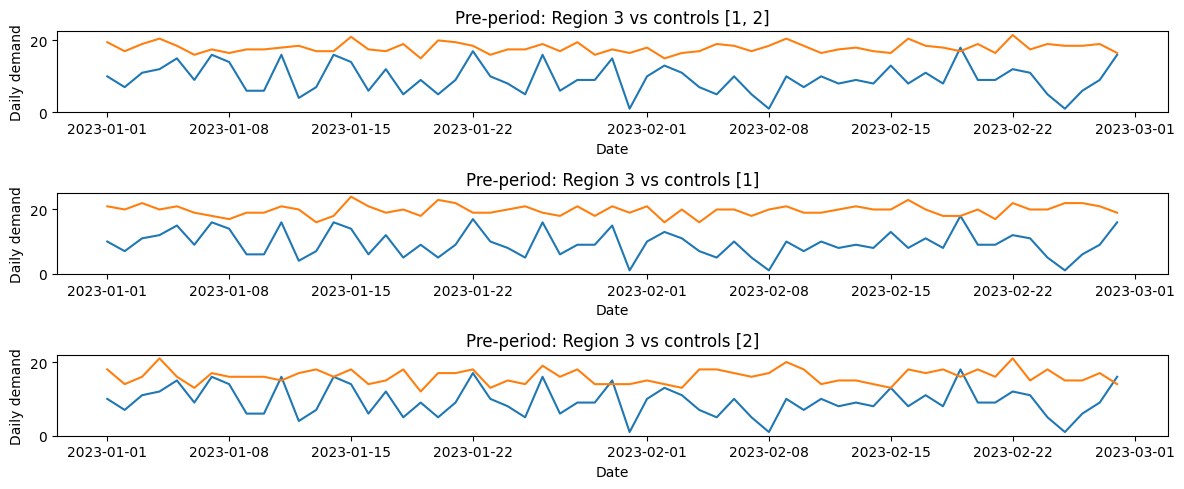

Pre-period slope diff (t:treat) for R4 vs [1, 2]: -0.022 (p=0.572)
Pre-period slope diff (t:treat) for R4 vs [1]: -0.024 (p=0.551)
Pre-period slope diff (t:treat) for R4 vs [2]: -0.021 (p=0.613)


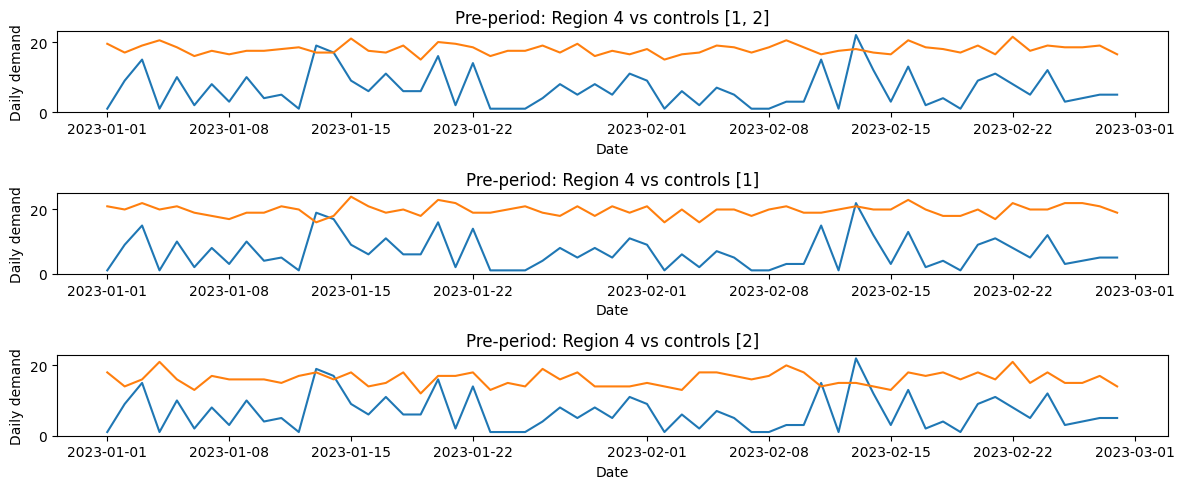

In [78]:
def parallel_trend_test(df, treated_region, control_regions, axes):
    # Set cutoff date
    cutoff = pd.to_datetime("2023-03-01")

    # Daily totals by region
    daily = (df.groupby(["Date","Region"])["Quantity Ordered"].sum().reset_index())
    pre = daily[daily["Date"] < cutoff].copy()

    # Treated series and control average (align on dates)
    tr = (pre[pre["Region"] == treated_region].groupby("Date")["Quantity Ordered"].sum().rename("treated"))
    ctrl = (pre[pre["Region"].isin(control_regions)].groupby("Date")["Quantity Ordered"].mean().rename("control"))
    aligned = pd.concat([tr, ctrl], axis=1).dropna()

    axes.plot(aligned.index, aligned["treated"], label=f"Region {treated_region}", color="tab:blue")
    axes.plot(aligned.index, aligned["control"], label=f"Controls avg {control_regions}", color="tab:orange")
    axes.set_xlabel("Date")
    axes.set_ylabel("Daily demand")
    axes.set_title(f"Pre-period: Region {treated_region} vs controls {control_regions}")
    # Pre-period slope test: qty ~ t + treat + t:treat (H0: t:treat = 0)
    tr_df = aligned["treated"].reset_index().rename(columns={"treated":"qty"})
    tr_df["treat"] = 1
    ctrl_df = aligned["control"].reset_index().rename(columns={"control":"qty"})
    ctrl_df["treat"] = 0
    reg_df = pd.concat([tr_df, ctrl_df], ignore_index=True)
    reg_df["t"] = (reg_df["Date"] - reg_df["Date"].min()).dt.days

    res = smf.ols("qty ~ t + treat + t:treat", data=reg_df).fit(cov_type="HC1")
    coef = res.params.get("t:treat", float("nan"))
    pval = res.pvalues.get("t:treat", float("nan"))
    print(f"Pre-period slope diff (t:treat) for R{treated_region} vs {control_regions}: {coef:.3f} (p={pval:.3f})")
    return res

fig, axes = plt.subplots(3, 1, figsize=(12,5))
# Run for both treated regions with controls [1, 2]
parallel_trend_test(df, treated_region=3, control_regions=[1,2], axes=axes[0])
parallel_trend_test(df, treated_region=3, control_regions=[1], axes=axes[1])
parallel_trend_test(df, treated_region=3, control_regions=[2], axes=axes[2])
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12,5))
# Run for both treated regions with controls [1, 2]
parallel_trend_test(df, treated_region=4, control_regions=[1,2], axes=axes[0])
parallel_trend_test(df, treated_region=4, control_regions=[1], axes=axes[1])
parallel_trend_test(df, treated_region=4, control_regions=[2], axes=axes[2])
fig.tight_layout()
plt.show()

# 5. Spillover tests
From the graph in step 3, We suspect the control group seems affected by treatment group's discount (demande dropped slightly), it is important to check there is no spillover before proceding to the DiD methode for analying the effect of discount on region 3 and 4.

**Tests run:**
- Controls-only placebo DiD: Q ~ Region FE + Date FE + (R2 × post).
- Controls gap breakpoint: (R2 − R1) ~ time + post.
- All regions with post shifts: Q ~ Region FE + Date FE + R2×post + R3×post + R4×post.

**Results:**

- Placebo DiD: R2×post insignificant (p=0.814).
- Breakpoint: post shift in R2−R1 insignificant (p=0.791).
- All regions: R2×post insignificant (p=0.869); R3×post ≈ 6.78 (p<0.001); R4×post ≈ 3.87 (p<0.001).

**Interpretation:**

No evidence of spillover among controls; strong treatment effects in R3 and R4.
Decision: proceed with DiD using pooled controls (R1+R2), include Date FE and use robust SE (preferably clustered by Date).


=== Spillover diagnostics ===
[Controls-only placebo DiD] ATT (R2×post vs R1) = 0.104 (SE 0.442, p=0.815)
[Controls R2−R1 breakpoint] post shift = 0.230, p=0.791


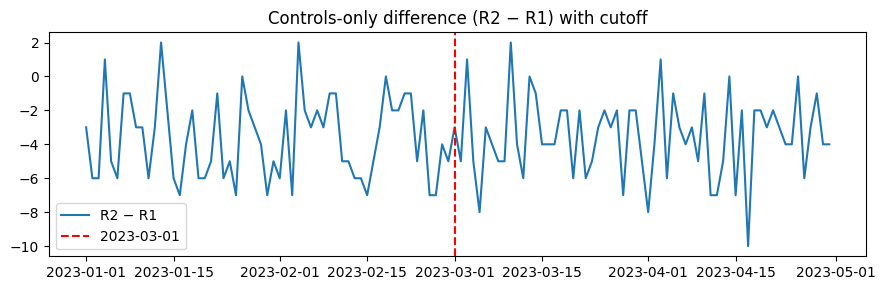

[All regions] R2xpost = 0.104, p=0.815
[All regions] R3xpost = 6.782, p=0.000
[All regions] R4xpost = 3.873, p=0.000
No evidence of spillover into controls → Use both R1 and R2 as control in DiD.


In [79]:
cutoff = pd.to_datetime("2023-03-01")

# Daily region totals
daily = (df.groupby(["Date","Region"])["Quantity Ordered"]
           .sum()
           .reset_index(name="Q"))
daily["Date"] = pd.to_datetime(daily["Date"])
daily["post"] = (daily["Date"] >= cutoff).astype(int)

def placebo_did_controls(daily):
    # Controls-only panel: treatC = 1 for Region 2, 0 for Region 1
    d_ctrl = daily[daily["Region"].isin([1, 2])].copy()
    d_ctrl["treatC"] = (d_ctrl["Region"] == 2).astype(int)

    # Classic DiD: Q ~ treat + post + treat×post (no FE)
    m = smf.ols("Q ~ treatC + post + treatC:post", data=d_ctrl).fit(
        cov_type="cluster", cov_kwds={"groups": d_ctrl["Date"]}
    )
    theta = m.params.get("treatC:post", np.nan)
    se = m.bse.get("treatC:post", np.nan)
    pval = m.pvalues.get("treatC:post", np.nan)
    print(f"[Controls-only placebo DiD] ATT (R2×post vs R1) = {theta:.3f} (SE {se:.3f}, p={pval:.3f})")
    return m

def controls_diff_breakpoint(daily):
    # Build R2-R1 difference series
    pivot = (daily[daily["Region"].isin([1,2])]
             .pivot(index="Date", columns="Region", values="Q")
             .dropna()
             .rename(columns={1:"R1",2:"R2"}))
    pivot["diff"] = pivot["R2"] - pivot["R1"]
    pivot["t"] = (pivot.index - pivot.index.min()).days
    pivot["post"] = (pivot.index >= cutoff).astype(int)
    X = sm.add_constant(pivot[["t","post"]])
    res = sm.OLS(pivot["diff"], X).fit(cov_type="HC1")
    b_post = res.params.get("post", np.nan)
    p_post = res.pvalues.get("post", np.nan)
    print(f"[Controls R2−R1 breakpoint] post shift = {b_post:.3f}, p={p_post:.3f}")

    # Plot the difference with cutoff
    plt.figure(figsize=(9,3))
    plt.plot(pivot.index, pivot["diff"], label="R2 − R1")
    plt.axvline(cutoff, color="red", linestyle="--", label="2023-03-01")
    plt.title("Controls-only difference (R2 − R1) with cutoff")
    plt.legend(); plt.tight_layout(); plt.show()
    return res

def all_regions_with_ctrl_shift(daily):
    d = daily.copy()
    # Group dummies
    d["R2"] = (d["Region"] == 2).astype(int)
    d["R3"] = (d["Region"] == 3).astype(int)
    d["R4"] = (d["Region"] == 4).astype(int)
    # Classic DiD interactions
    d["R2xpost"] = d["R2"] * d["post"]
    d["R3xpost"] = d["R3"] * d["post"]
    d["R4xpost"] = d["R4"] * d["post"]

    # Classic multi-arm DiD: Q ~ group dummies + post + group×post (no FE)
    mod = smf.ols("Q ~ R2 + R3 + R4 + post + R2xpost + R3xpost + R4xpost", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["Date"]}
    )
    for k in ["R2xpost", "R3xpost", "R4xpost"]:
        print(f"[All regions] {k} = {mod.params.get(k, np.nan):.3f}, p={mod.pvalues.get(k, np.nan):.3f}")
    return mod

print("=== Spillover diagnostics ===")
m1 = placebo_did_controls(daily)
m2 = controls_diff_breakpoint(daily)
m3 = all_regions_with_ctrl_shift(daily)

p_ctrl_placebo = m1.pvalues.get("treatC:post", np.nan)
p_ctrl_shift   = m2.pvalues.get("post", np.nan)
p_R2xpost      = m3.pvalues.get("R2xpost", np.nan)

if (p_ctrl_placebo > 0.10) and (p_ctrl_shift > 0.10) and (p_R2xpost > 0.10):
    print("No evidence of spillover into controls → Use both R1 and R2 as control in DiD.")
else:
    print("Potential spillover or differential shift in controls → Prefer the cleaner control only (R1 or R2).")

# 6. DiD for region 1,2,3 in order to get the Unit Price Discount Effect (Region 3)

In [60]:
cutoff = pd.to_datetime("2023-03-01")

# Daily panel
daily = (df.groupby(["Date","Region"])
            .agg(Q=("Quantity Ordered","sum"),
                Price=("Unit Price","mean"),
                Distance=("Distance","mean"),
                fee_per_km=("delivery_fee_per_km","mean"))
            .reset_index())
daily["Date"] = pd.to_datetime(daily["Date"])
daily["post"] = (daily["Date"] >= cutoff).astype(int)

def did_model_R3_classic(daily):
    d = daily[daily["Region"].isin([1, 2, 3])].copy()
    d["treat3"] = (d["Region"] == 3).astype(int)
    # Classic DiD: Q ~ treat + post + treat×post (no Date FE)
    return smf.ols("Q ~ treat3 + post + treat3:post", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["Date"]}
    )

mod3 = did_model_R3_classic(daily)
b3 = mod3.params.get("treat3:post", np.nan)
se3 = mod3.bse.get("treat3:post", np.nan)
p3  = mod3.pvalues.get("treat3:post", np.nan)

print("=== R3 (classic DiD: treat + post + treat×post) ===")
print(mod3.summary())
print(f"  ATT (treat3×post): {b3:.3f} pizzas/day")
print(f"  Std. Error (clustered by Date): {se3:.3f}")
print(f"  p-value: {p3:.4f}")
print(f"  → 5% price discount → {'SIGNIFICANT' if p3 < 0.05 else 'NOT SIGNIFICANT'} increase in demand")


=== R3 (classic DiD: treat + post + treat×post) ===
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     80.26
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.85e-28
Time:                        18:37:20   Log-Likelihood:                -897.16
No. Observations:                 360   AIC:                             1802.
Df Residuals:                     356   BIC:                             1818.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

# 7. DiD for region 1,2,4 in order to get the Unit Delivery Discount Effect (Region 4)

In [59]:
def did_model_R4_classic(daily):
    d = daily[daily["Region"].isin([1, 2, 4])].copy()
    d["treat4"] = (d["Region"] == 4).astype(int)
    # Classic DiD: Q ~ treat + post + treat×post (no Date FE)
    return smf.ols("Q ~ treat4 + post + treat4:post", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["Date"]}
    )

mod4 = did_model_R4_classic(daily)
b4 = mod4.params.get("treat4:post", np.nan)
se4 = mod4.bse.get("treat4:post", np.nan)
p4  = mod4.pvalues.get("treat4:post", np.nan)

print("=== R4 (classic DiD: treat + post + treat×post) ===")
print(mod4.summary())
print(f"  ATT (treat4×post): {b4:.3f} pizzas/day")
print(f"  Std. Error (clustered by Date): {se4:.3f}")
print(f"  p-value: {p4:.4f}")
print(f"  → 5% delivery fee discount → {'SIGNIFICANT' if p4 < 0.05 else 'NOT SIGNIFICANT'} increase in demand")


=== R4 (classic DiD: treat + post + treat×post) ===
                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     157.3
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           3.09e-41
Time:                        18:36:04   Log-Likelihood:                -945.08
No. Observations:                 360   AIC:                             1898.
Df Residuals:                     356   BIC:                             1914.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

# 8. Calculate the best price based on Did 6 and 7 result

In [62]:
dQ3 = float(b3)
dQ4 = float(b4)
unit_cost = 4.0
delivery_cost_per_km = 0.5
def prepost_stats(d, r):
    d_r = d[d["Region"]==r]
    pre = d_r[d_r["post"]==0]
    post = d_r[d_r["post"]==1]
    return {
        "Q0": pre["Q"].mean(),
        "P0": pre["Price"].mean(),
        "P1": post["Price"].mean(),
        "r0": pre["fee_per_km"].mean(),
        "r1": post["fee_per_km"].mean(),
        "Dbar": d_r["Distance"].mean()
    }

s3 = prepost_stats(daily, 3)
s4 = prepost_stats(daily, 4)

# Region 3: demand in price
dP3 = s3["P1"] - s3["P0"]
B3 = dQ3 / dP3
A3 = s3["Q0"] - B3 * s3["P0"]
P_star_3 = (B3*unit_cost - A3) / (2*B3)

# Region 4: demand in delivery rate per km
dr4 = s4["r1"] - s4["r0"]
C4 = dQ4 / dr4
A4 = s4["Q0"] - C4 * s4["r0"]
Dbar4 = s4["Dbar"]
r_star_4 = -(Dbar4*A4+C4*(s4["P0"]-unit_cost-Dbar4*delivery_cost_per_km))/(2*C4*Dbar4)

print("=== Demand functions (DiD-based) ===")
print(f"Region 3: Q ≈ {A3:.2f} + ({B3:.2f})·Price   | ΔQ={dQ3:.2f}, ΔP={dP3:.2f}")
print(f"Region 4: Q ≈ {A4:.2f} + ({C4:.2f})·Rate/km  | ΔQ={dQ4:.2f}, Δr={dr4:.3f}")
print("\n=== Profit-maximizing recommendations ===")
print(f"Region 3: Optimal unit price P* ≈ {P_star_3:.2f} (unit cost c={unit_cost:.2f})")
print(f"Region 4: Optimal delivery rate r* ≈ {r_star_4:.3f} (c_d={delivery_cost_per_km:.2f}, D̄≈{Dbar4:.2f})")

=== Demand functions (DiD-based) ===
Region 3: Q ≈ 144.01 + (-8.41)·Price   | ΔQ=6.73, ΔP=-0.80
Region 4: Q ≈ 83.06 + (-152.84)·Rate/km  | ΔQ=3.82, Δr=-0.025

=== Profit-maximizing recommendations ===
Region 3: Optimal unit price P* ≈ 10.56 (unit cost c=4.00)
Region 4: Optimal delivery rate r* ≈ 0.122 (c_d=0.50, D̄≈15.00)


# 9. The Pizza price and delivery fee can have a joint effect, let's use both of them to analyse the result.

In [72]:
# --- Simultaneous DiD on daily panel with Region & Date FE, clustered by Date ---
d = daily.copy()
d["R3"] = (d["Region"] == 3).astype(int)
d["R4"] = (d["Region"] == 4).astype(int)
d["R3xpost"] = d["R3"] * d["post"]
d["R4xpost"] = d["R4"] * d["post"]

mod_both = smf.ols("Q ~ R3 + R4 + post + R3xpost + R4xpost", data=d).fit(
    cov_type="cluster", cov_kwds={"groups": d["Date"]}
)
print(mod_both.summary())

# Key coefficients, 95% CI and p-values
for k in ["R3xpost","R4xpost"]:
    b = mod_both.params.get(k, float("nan"))
    se = mod_both.bse.get(k, float("nan"))
    p  = mod_both.pvalues.get(k, float("nan"))
    ci = mod_both.conf_int().loc[k].values if k in mod_both.conf_int().index else (float("nan"), float("nan"))
    print(f"{k}: {b:.3f} (SE {se:.3f}, p={p:.4f}, 95% CI [{ci[0]:.3f}, {ci[1]:.3f}])")

# Elasticities/slopes implied by the known policy changes (uses s3/s4 you computed above)
dQ3_both = mod_both.params.get("R3xpost", float("nan"))
dQ4_both = mod_both.params.get("R4xpost", float("nan"))

dP3 = s3["P1"] - s3["P0"]
dr4 = s4["r1"] - s4["r0"]
dQ3_eff = float(mod_both.params.get("R3xpost"))
dQ4_eff = float(mod_both.params.get("R4xpost"))
# Demand and optima
B3 = dQ3_eff / dP3
A3 = s3["Q0"] - B3 * s3["P0"]
P_star_3 = (B3*unit_cost - A3) / (2*B3)

C4 = dQ4_eff / dr4
A4 = s4["Q0"] - C4 * s4["r0"]
Dbar4 = s4["Dbar"]
r_star_4 = -(Dbar4*A4 + C4*(s4["P0"] - unit_cost - Dbar4*delivery_cost_per_km)) / (2*C4*Dbar4)

# Back-of-envelope daily profit deltas
Q0_3, P0_3, P1_3 = s3["Q0"], s3["P0"], s3["P1"]
d_profit_3 = Q0_3*(P1_3 - P0_3) + dQ3_eff*(P1_3 - unit_cost)

Q0_4, P0_4, r0_4, r1_4 = s4["Q0"], s4["P0"], s4["r0"], s4["r1"]
d_profit_4 = dQ4_eff*((P0_4 - unit_cost) + Dbar4*(r1_4 - delivery_cost_per_km)) + Q0_4*Dbar4*(r1_4 - r0_4)

global_pick = "price_5pct" if d_profit_3 > d_profit_4 else "delivery_5pct"

print(f"Global best single promo: {global_pick} (Δπ R3≈{d_profit_3:.2f} vs Δπ R4≈{d_profit_4:.2f})")
print(f"Per-region if allowed → R3: set unit price to ≈ {P_star_3:.2f}; R4: set rate/km to ≈ {r_star_4:.3f}")

                            OLS Regression Results                            
Dep. Variable:                      Q   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     124.8
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.30e-45
Time:                        19:12:09   Log-Likelihood:                -1267.1
No. Observations:                 480   AIC:                             2546.
Df Residuals:                     474   BIC:                             2571.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.9322      0.185     97.007      0.0

# 10. Multi-arm Bandit

Goal
- Learn which promo (arm) maximizes profit by selecting an arm each order and updating from observed profit.

Arms
- no_discount, price_5pct (5% off unit price), delivery_5pct (5% off delivery rate).

Reward (per order)
- profit_per_order = (Unit Price − 4.0) × Quantity + (Delivery Fees − 0.5 × Distance).
- Includes both product margin and delivery margin.

What the code does
- Builds historical “profit pools” for each arm from GP3_Data.csv.
- Runs several learning policies over n_rounds orders:
  - N-Average (explore each arm n times, then commit),
  - Epsilon-Greedy (ε exploration),
  - UCB1 (optimism bonus),
  - Thompson Sampling (Gaussian prior on mean reward).
- Tracks and plots cumulative simulated profit for each policy and prints the final totals.

How to interpret
- This is an offline illustration (replay-style sampling), not a causal estimate.
- Assumes stationarity and ignores context; results show how each policy would behave if deployed online with similar reward distributions.
- Higher final cumulative profit indicates faster/better learning given these historical profit pools.

When to use which
- If allowed to vary offers per order/user: deploy Thompson or UCB1 online and update after each checkout.
- If offers must be uniform per day/region: run a day-level bandit (reward = day profit) instead.

Possible extensions
- Contextual bandit (weekday, distance, new vs returning).
- Guardrails (price floors, budget/exposure caps), and reproducible seeding for simulations.



=== Strategy performance based on historical data ===
        Strategy  avg_profit_per_order  total_profit  num_orders
0  delivery_5pct             99.509375     11941.125         120
1    no_discount            211.850000     50844.000         240
2     price_5pct            144.260000     17311.200         120



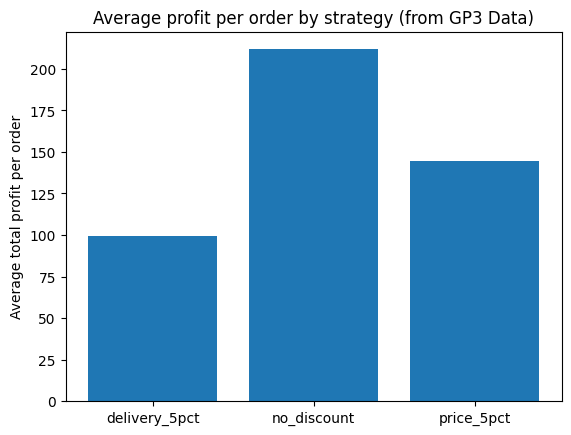

no_discount: 240 samples
price_5pct: 120 samples
delivery_5pct: 120 samples
=== Final cumulative simulated profit by bandit policy ===
          policy  cum_reward
0  EpsilonGreedy  413169.125
1      N-Average  420337.475
2       Thompson  424748.425
3           UCB1  423193.600


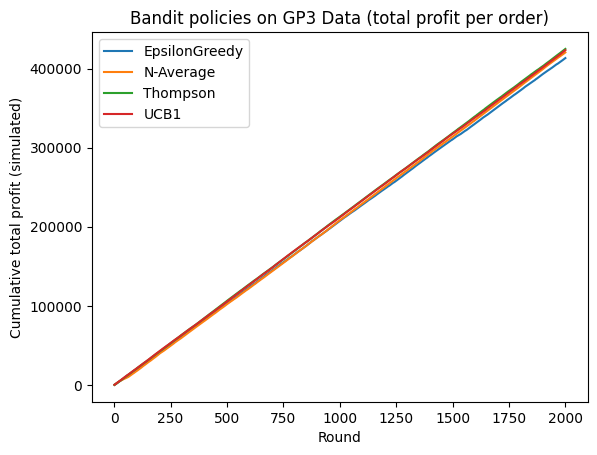

In [82]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

np.random.seed(42)
# =========================
# 1. Load data & compute profit per ORDER
# =========================
df = pd.read_csv("GP3_Data.csv", parse_dates=["Date"])

COL_DATE = "Date"
COL_REGION = "Region"
COL_PRICE = "Unit Price"
COL_QTY = "Quantity Ordered"
COL_DISTANCE = "Distance"
COL_DELIVERY = "Delivery Fees"
COL_DISCOUNT_FLAG = "Discount Applied"
DELIV_COST_PER_KM = 0.5
UNIT_COST = 4.0  # pizza unit cost

# Keep valid rows
df = df[df[COL_QTY] > 0].copy()

# Total profit per order = (unit price - unit cost) * quantity
df["profit_per_order"] = (
    (df[COL_PRICE] - UNIT_COST) * df[COL_QTY]
    + (df[COL_DELIVERY] - DELIV_COST_PER_KM * df[COL_DISTANCE])
)

# =========================
# 2. Region → Strategy mapping (TRUE MAPPING)
# =========================
REGION_TO_STRATEGY = {
    1: "no_discount",
    2: "no_discount",
    3: "price_5pct",
    4: "delivery_5pct"
}

df["Strategy"] = df[COL_REGION].map(REGION_TO_STRATEGY)
df = df.dropna(subset=["Strategy"])

ARMS = ["no_discount", "price_5pct", "delivery_5pct"]

# =========================
# 3. DIRECT COMPARISON: which strategy is better?
# =========================
strategy_stats = (
    df.groupby("Strategy")["profit_per_order"]
      .agg(
          avg_profit_per_order="mean",
          total_profit="sum",
          num_orders="count"
      )
      .reset_index()
)

print("=== Strategy performance based on historical data ===")
print(strategy_stats)
print()

# Optional: quick bar plot of average profit per order
plt.figure()
plt.bar(strategy_stats["Strategy"], strategy_stats["avg_profit_per_order"])
plt.ylabel("Average total profit per order")
plt.title("Average profit per order by strategy (from GP3 Data)")
plt.show()

# =========================
# 4. Build historical profit pools for each arm (for bandit sim)
# =========================
profit_pools = {
    arm: df.loc[df["Strategy"] == arm, "profit_per_order"].values
    for arm in ARMS
}

for arm in ARMS:
    print(f"{arm}: {profit_pools[arm].shape[0]} samples")

def reward_func(arm: str) -> float:
    """
    Reward = total profit per ORDER, sampled from historical
    observations for the chosen strategy.
    """
    pool = profit_pools[arm]
    if len(pool) == 0:
        raise ValueError(f"No data for arm {arm}.")
    return float(np.random.choice(pool))

# =========================
# 5. Generic bandit runner
# =========================
def run_bandit(policy, n_rounds: int, name: str) -> pd.DataFrame:
    history = []
    for t in range(1, n_rounds + 1):
        arm = policy.select_arm()
        reward = reward_func(arm)
        policy.update(arm, reward)
        history.append({"t": t, "arm": arm, "reward": reward})

    hist_df = pd.DataFrame(history)
    hist_df["cum_reward"] = hist_df["reward"].cumsum()
    hist_df["policy"] = name
    return hist_df

# =========================
# 6. Bandit algorithms
# =========================
@dataclass
class NAverageBandit:
    arms: list
    n_init: int = 20
    counts: dict = field(default_factory=dict)
    values: dict = field(default_factory=dict)
    committed_arm: str | None = None

    def __post_init__(self):
        self.counts = {arm: 0 for arm in self.arms}
        self.values = {arm: 0.0 for arm in self.arms}

    def select_arm(self) -> str:
        for arm in self.arms:
            if self.counts[arm] < self.n_init:
                return arm
        if self.committed_arm is None:
            self.committed_arm = max(self.arms, key=lambda a: self.values[a])
        return self.committed_arm

    def update(self, arm: str, reward: float):
        self.counts[arm] += 1
        n = self.counts[arm]
        old = self.values[arm]
        self.values[arm] = old + (reward - old) / n


@dataclass
class EpsilonGreedyBandit:
    arms: list
    epsilon: float = 0.1   # exploration probability
    counts: dict = field(default_factory=dict)
    values: dict = field(default_factory=dict)

    def __post_init__(self):
        self.counts = {arm: 0 for arm in self.arms}
        self.values = {arm: 0.0 for arm in self.arms}

    def select_arm(self) -> str:
        # Make sure each arm is tried at least once
        for arm in self.arms:
            if self.counts[arm] == 0:
                return arm

        # With probability epsilon -> explore (random arm)
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.arms)

        # With probability 1 - epsilon -> exploit (best current mean)
        return max(self.arms, key=lambda a: self.values[a])

    def update(self, arm: str, reward: float):
        self.counts[arm] += 1
        n = self.counts[arm]
        old = self.values[arm]
        self.values[arm] = old + (reward - old) / n


@dataclass
class UCB1Bandit:
    arms: list
    c: float = 1.0
    counts: dict = field(default_factory=dict)
    values: dict = field(default_factory=dict)
    t: int = 0

    def __post_init__(self):
        self.counts = {arm: 0 for arm in self.arms}
        self.values = {arm: 0.0 for arm in self.arms}

    def select_arm(self) -> str:
        self.t += 1
        for arm in self.arms:
            if self.counts[arm] == 0:
                return arm

        scores = {}
        for arm in self.arms:
            mean = self.values[arm]
            n = self.counts[arm]
            bonus = self.c * np.sqrt(2 * np.log(self.t) / n)
            scores[arm] = mean + bonus

        return max(self.arms, key=lambda a: scores[a])

    def update(self, arm: str, reward: float):
        self.counts[arm] += 1
        n = self.counts[arm]
        old = self.values[arm]
        self.values[arm] = old + (reward - old) / n


@dataclass
class ThompsonGaussianBandit:
    arms: list
    prior_mean: float = 0.0
    prior_std: float = 20.0
    counts: dict = field(default_factory=dict)
    sum_rewards: dict = field(default_factory=dict)

    def __post_init__(self):
        self.counts = {arm: 0 for arm in self.arms}
        self.sum_rewards = {arm: 0.0 for arm in self.arms}

    def select_arm(self) -> str:
        samples = {}
        for arm in self.arms:
            n = self.counts[arm]
            if n == 0:
                mu = self.prior_mean
                sigma = self.prior_std
            else:
                mu = self.sum_rewards[arm] / n
                sigma = self.prior_std / np.sqrt(n + 1)
            samples[arm] = np.random.normal(mu, sigma)
        return max(self.arms, key=lambda a: samples[a])

    def update(self, arm: str, reward: float):
        self.counts[arm] += 1
        self.sum_rewards[arm] += reward

# =========================
# 7. Run bandits (optional, to see “learning” vs fixed strategies)
# =========================
if __name__ == "__main__":
    # 1) Direct comparison already printed above (strategy_stats)
    # 2) Optionally run bandit policies to see how they learn

    n_rounds = 2000

    n_avg = NAverageBandit(ARMS, n_init=20)
    epsilongreedy = EpsilonGreedyBandit(ARMS)
    ucb = UCB1Bandit(ARMS, c=1.0)
    ts = ThompsonGaussianBandit(ARMS, prior_mean=strategy_stats["avg_profit_per_order"].mean(),
                                prior_std=20.0)

    hist_n_avg = run_bandit(n_avg, n_rounds, "N-Average")
    hist_epsilongreedy = run_bandit(epsilongreedy, n_rounds, "EpsilonGreedy")
    hist_ucb = run_bandit(ucb, n_rounds, "UCB1")
    hist_ts = run_bandit(ts, n_rounds, "Thompson")

    all_hist = pd.concat(
        [hist_n_avg, hist_epsilongreedy, hist_ucb, hist_ts],
        ignore_index=True
    )

    print("=== Final cumulative simulated profit by bandit policy ===")
    final = (
        all_hist.sort_values(["policy", "t"])
                .groupby("policy")["cum_reward"]
                .last()
                .reset_index()
    )
    print(final)

    for name, g in all_hist.groupby("policy"):
        plt.plot(g["t"], g["cum_reward"], label=name)
    plt.xlabel("Round")
    plt.ylabel("Cumulative total profit (simulated)")
    plt.legend()
    plt.title("Bandit policies on GP3 Data (total profit per order)")
    plt.show()